(sw_tomography_sphere_global)=

# Global Surface-Wave Tomography in Spherical Coordinates

This tutorial extends {ref}`sw_tomography_sphere` to the entire Earth. At the global scale, longitude and latitude cannot be treated as Cartesian coordinates: both the source-receiver paths and the model geometry must account for the curvature and periodicity of the sphere. As in the continental example, we use [bayesbay.discretization.Voronoi2DSphere](../api/generated/bayesbay.discretization.Voronoi2DSphere), a trans-dimensional Voronoi tessellation defined in terms of great-circle distances, with sites expressed as longitude-latitude pairs in degrees.

The tutorial illustrates three features of `Voronoi2DSphere`:

- **Full-sphere domain**: no polygon is supplied, so the Voronoi sites can occupy the whole sphere and their position prior is uniform per unit surface area;
- **Global acquisition geometry**: synthetic earthquakes follow simplified major seismic belts, and receivers are placed randomly on the world's land masses;
- **Interpolation of the tessellation**: by registering the forward grid through `interpolation_positions`, each Markov chain state keeps track of the Voronoi cell each grid node belongs to, and the forward function interpolates the tessellation through a simple array lookup (see the note below).

## Import libraries and define constants

As in {ref}`sw_tomography_sphere`, we use [SeisLib](https://seislib.readthedocs.io/en/latest/) to construct a global equal-area grid and to compute the Jacobian of great-circle paths. We also use [Cartopy](https://scitools.org.uk/cartopy/) to display global maps and to constrain the receivers to dry land.

In [1]:
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.cm import ScalarMappable
import scipy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import shapely.geometry
import shapely.ops
import shapely.prepared

from seislib.tomography import SeismicTomography
from cmcrameri import cm as scm

from bayesbay.discretization import Voronoi2DSphere
from bayesbay.prior import UniformPrior
import bayesbay as bb

random.seed(10)
np.random.seed(10)
rng = np.random.default_rng(10)

## Global grid and true velocity model

The model domain covers the full sphere. SeisLib constructs an equal-area grid: every cell covers the same surface area, although the longitude width of the cells changes with latitude. The true velocity model is a global checkerboard of alternating fast and slow anomalies (±0.25 km/s around 3 km/s), arranged in 45°-by-45° blocks. We do not use SeisLib's built-in checkerboard, which tapers the anomalies with the cosine of latitude. Instead, we sharpen a product of sinusoids through the `sharpness` exponent below, so that each anomaly plateaus near its full amplitude and the pattern does not fade towards the poles.

In [2]:
tomo = SeismicTomography(
    cell_size=3,
    lonmin=-180,
    lonmax=180,
    latmin=-90,
    latmax=90,
    verbose=False,
)
grid_points = np.column_stack(tomo.grid.midpoints_lon_lat())


def checkerboard(lon, lat, ref_value=3, anom_amp=0.25, kx=8, ky=4, sharpness=0.3):
    """Checkerboard of kx-by-ky anomalies that do not fade towards the poles."""
    pattern = np.sin(np.radians(lon) * kx / 2) * np.sin(np.radians(lat + 90) * ky)
    return ref_value + anom_amp * np.sign(pattern) * np.abs(pattern) ** sharpness


vel_true = checkerboard(*grid_points.T)
print(f"{grid_points.shape[0]} equal-area grid cells")

4584 equal-area grid cells


The same global projection and colour scale are used throughout the tutorial. Unlike in the continental-scale example, there is no polygon to mask or draw.

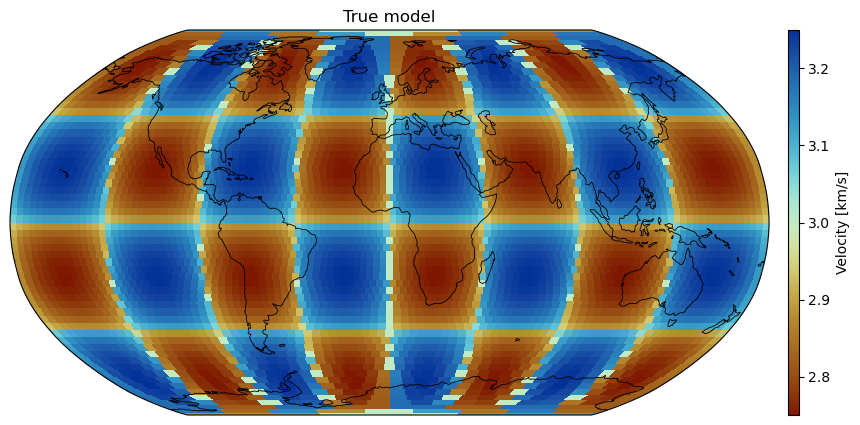

In [3]:
def plot_map(values, title, ax=None, cbar_label="Velocity [km/s]", **kwargs):
    if ax is None:
        plt.figure(figsize=(12, 5))
        ax = plt.axes(projection=ccrs.Robinson())
    image = tomo.plot_map(
        tomo.grid.mesh,
        values,
        ax=ax,
        colorbar=False,
        show=False,
        style="colormesh",
        cmap=scm.roma,
        **kwargs,
    )
    ax.coastlines(resolution="110m", lw=0.6)
    ax.set_global()
    cbar = ax.figure.colorbar(image, ax=ax, aspect=35, pad=0.02)
    cbar.set_label(cbar_label)
    ax.set_title(title)
    return ax, cbar


plot_map(vel_true, "True model", vmin=vel_true.min(), vmax=vel_true.max())
plt.show()

## Observed Data

The code block below generates a reproducible global acquisition geometry. Receivers are drawn randomly on dry land between 60°S and 75°N, excluding Antarctica and the most inaccessible polar regions. The earthquakes are synthetic: they are sampled, with a small amount of spatial scatter, along simplified representations of the major seismic belts. These include the circum-Pacific Ring of Fire (the Aleutian, Kamchatka–Kuril–Japan–Mariana, Philippine, New Guinea–Vanuatu, Tonga–Kermadec and Sunda subduction zones, and the active margin of the Americas), the Alpine–Himalayan belt, the mid-ocean ridges (Mid-Atlantic, Indian Ocean, East Pacific Rise and Pacific–Antarctic), the East African Rift, and the Caribbean and Scotia arcs. This mimics the strongly non-uniform distribution of real seismicity without downloading an earthquake catalogue.

Using SeisLib, we then compute the $m \times n$ Jacobian matrix $\mathbf{G}$, where $m$ denotes the number of source-receiver pairs (here, 12,000) and $n$ the number of grid cells defining the velocity medium. $\mathbf{G}$ is defined such that $G_{ij} = \frac{l_j}{L_i}$, where $L_i$ is the great-circle length associated with the $i$th observation and $l_j$ is its segment within the $j$th grid cell ([Magrini et al. 2022](Magrini22b_global)). All paths are computed along great circles on the sphere.

As in {ref}`sw_tomography_sphere`, we use the Jacobian matrix to define the observed surface-wave arrival times $\mathbf{d}_{obs} = \mathbf{G} \cdot \mathbf{s}_{true}$, where $\mathbf{s}_{true}$ denotes the reciprocal of the true velocity model.

In [4]:
TECTONIC_BELTS = [
    # Circum-Pacific Ring of Fire: Aleutian arc
    [(-148, 60), (-155, 57), (-165, 54), (-175, 52), (180, 51), (172, 52),
     (165, 54)],
    # Kamchatka, Kuril, Japan, Izu-Bonin and Mariana trenches
    [(162, 56), (157, 51), (152, 46), (146, 42), (142, 37), (140, 32),
     (142, 26), (145, 19), (147, 13)],
    # Ryukyu arc and Philippine trench
    [(131, 31), (128, 27), (123, 22), (121, 17), (124, 11), (126, 6),
     (128, 1)],
    # New Guinea, Solomon Islands and Vanuatu
    [(133, -2), (140, -4), (148, -6), (155, -7), (161, -10), (167, -15),
     (172, -19)],
    # Tonga-Kermadec trench and New Zealand
    [(-173, -16), (-174, -22), (-176, -28), (179, -33), (177, -38),
     (172, -43), (167, -47)],
    # Active margin of the Americas: Alaska, Cascadia, Mexico, Central
    # America and the Andes
    [(-148, 60), (-140, 59), (-133, 54), (-128, 49), (-124, 44), (-122, 38),
     (-116, 32), (-109, 25), (-104, 19), (-96, 15), (-90, 13), (-85, 10),
     (-82, 5), (-80, -1), (-78, -8), (-74, -16), (-71, -24), (-71, -33),
     (-73, -41), (-75, -49)],
    # Alpine-Himalayan belt: Mediterranean, Anatolia, Zagros, Himalaya
    # and Indo-Burma
    [(-8, 36), (3, 37), (14, 41), (23, 39), (31, 37), (40, 37), (48, 33),
     (56, 28), (63, 28), (71, 34), (79, 31), (87, 28), (94, 24)],
    # Sunda-Banda arc: Andaman Islands, Sumatra, Java and the Banda Sea
    [(93, 13), (95, 5), (99, -1), (104, -6), (110, -9), (117, -10),
     (123, -10), (129, -6)],
    # Mid-Atlantic Ridge
    [(-14, -47), (-12, -33), (-13, -18), (-15, -7), (-25, 1), (-32, 11),
     (-41, 24), (-42, 32), (-34, 43), (-28, 52), (-19, 60), (-17, 67),
     (-4, 72)],
    # Southwest Indian Ridge, from the Bouvet to the Rodrigues triple junction
    [(1, -54), (18, -51), (34, -46), (49, -38), (61, -31), (69, -25)],
    # Carlsberg Ridge, from the Rodrigues triple junction to the Gulf of Aden
    [(68, -21), (66, -10), (61, 0), (52, 10), (45, 12)],
    # East African Rift
    [(41, 12), (37, 5), (35, -2), (34, -9), (33, -16)],
    # Southeast Indian Ridge, up to the Macquarie triple junction
    [(71, -26), (78, -34), (88, -42), (100, -47), (115, -49), (130, -50),
     (145, -54), (159, -58)],
    # East Pacific Rise and Pacific-Antarctic Ridge
    [(-104, 10), (-103, 2), (-107, -8), (-111, -18), (-113, -27),
     (-114, -36), (-119, -46), (-133, -54), (-150, -60), (-170, -63)],
    # Caribbean and Scotia arcs
    [(-78, 19), (-70, 19), (-63, 18), (-60, 14), (-61, 10)],
    [(-60, -55), (-45, -60), (-31, -60), (-25, -57)],
]


def get_land_polygons():
    shp = shpreader.natural_earth(
        resolution="110m", category="physical", name="land"
    )
    land = shapely.ops.unary_union(list(shpreader.Reader(shp).geometries()))
    return shapely.prepared.prep(land)


def sample_tectonic_belts(n_sources):
    """Sample synthetic earthquakes along simplified major seismic belts."""
    candidates_xyz = []
    for belt in TECTONIC_BELTS:
        for start, end in zip(belt[:-1], belt[1:]):
            endpoints_xyz = Voronoi2DSphere.lonlat_to_xyz(
                np.asarray([start, end], dtype=float)
            )
            angle = np.arccos(np.clip(endpoints_xyz[0] @ endpoints_xyz[1], -1, 1))
            n_points = max(2, int(np.ceil(np.degrees(angle) / 2)))
            candidates_xyz.append(
                scipy.spatial.geometric_slerp(
                    endpoints_xyz[0],
                    endpoints_xyz[1],
                    np.linspace(0, 1, n_points, endpoint=False),
                )
            )
    candidates = Voronoi2DSphere.xyz_to_lonlat(np.vstack(candidates_xyz))
    sources_lonlat = candidates[
        rng.choice(len(candidates), n_sources, replace=False)
    ]
    sources_lonlat += rng.normal(scale=1.2, size=sources_lonlat.shape)
    sources_lonlat[:, 0] = (sources_lonlat[:, 0] + 180) % 360 - 180
    sources_lonlat[:, 1] = np.clip(sources_lonlat[:, 1], -80, 80)
    return sources_lonlat[:, ::-1]  # (latitude, longitude), as expected by SeisLib


def sample_land_receivers(n_receivers):
    """Draw receivers uniformly per unit area, retaining land locations."""
    land = get_land_polygons()
    sin_lat_min, sin_lat_max = np.sin(np.radians([-60, 75]))
    receivers = []
    while len(receivers) < n_receivers:
        longitude = rng.uniform(-180, 180)
        latitude = np.degrees(
            np.arcsin(rng.uniform(sin_lat_min, sin_lat_max))
        )
        if land.contains(shapely.geometry.Point(longitude, latitude)):
            receivers.append([latitude, longitude])
    return np.asarray(receivers)


def add_data_coords(tomo, sources, receivers):
    data_coords = np.zeros((sources.shape[0] * receivers.shape[0], 4))
    for icoord, (isource, ireceiver) in enumerate(
        np.ndindex((sources.shape[0], receivers.shape[0]))
    ):
        data_coords[icoord] = np.concatenate(
            (sources[isource], receivers[ireceiver])
        )
    tomo.data_coords = data_coords


def compute_jacobian(tomo):
    tomo.compile_coefficients()
    jacobian = scipy.sparse.csr_matrix(tomo.A)
    del tomo.A
    return jacobian


sources = sample_tectonic_belts(n_sources=150)
receivers = sample_land_receivers(n_receivers=80)
add_data_coords(tomo, sources, receivers)
jacobian = compute_jacobian(tomo)
d_obs = jacobian @ (1 / vel_true)

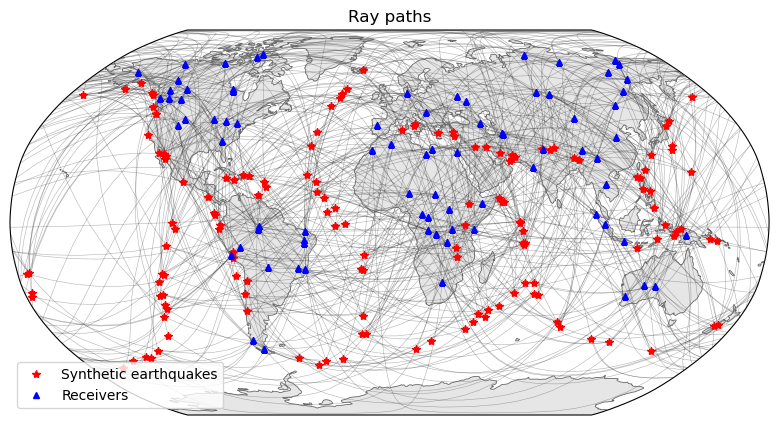

In [5]:
fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.add_feature(cfeature.LAND, facecolor="0.9")
# zorder=4 keeps the coastlines legible on top of the ray paths
ax.coastlines(resolution="110m", lw=0.6, color="0.4", zorder=4)
ax.set_global()
# Sources and receivers have columns (latitude, longitude); Cartopy's Geodetic
# transform draws the connecting rays along great circles.
geodetic = ccrs.Geodetic()
geodetic.threshold = 1e5
rays = [
    ((lon1, lat1), (lon2, lat2))
    for lat1, lon1, lat2, lon2 in tomo.data_coords
]
# Display a random subset of the paths for legibility; all 12,000 are used
# in the inversion. (A strided subset would repeatedly hit the same few
# receivers, since the data are ordered source by source.)
shown = rng.choice(len(rays), size=700, replace=False)
ray_collection = LineCollection(
    [rays[i] for i in shown],
    transform=geodetic,
    lw=0.4,
    color="0.15",
    alpha=0.35,
    clip_on=True,
    zorder=3,
)
ray_collection.set_clip_path(ax.patch)
ax.add_collection(ray_collection)
ax.plot(
    sources[:, 1], sources[:, 0], "r*", ms=6,
    transform=ccrs.PlateCarree(), label="Synthetic earthquakes", zorder=5
)
ax.plot(
    receivers[:, 1], receivers[:, 0], "b^", ms=4,
    transform=ccrs.PlateCarree(), label="Receivers", zorder=5
)
ax.set_title("Ray paths")
ax.legend(loc="lower left")
plt.show()

## Inference parameterization

We parameterize the velocity model through a trans-dimensional Voronoi tessellation on the sphere. The number of cells is a free parameter of the inversion, allowed to vary between 100 and 1500; within each cell, the velocity is uniformly distributed a priori between 2 and 4 km/s. Unlike in {ref}`sw_tomography_sphere`, no `polygon` is passed to `Voronoi2DSphere`: its domain is the full sphere. As before, `perturb_std` expresses the per-axis scale of the local tangent-plane site displacement, **in degrees**, and we register the equal-area grid through `interpolation_positions`, for use in the forward calculation below.

In [6]:
vel = UniformPrior("vel", vmin=2, vmax=4, perturb_std=0.1)
voronoi = Voronoi2DSphere(
    name="voronoi",
    perturb_std=4,
    n_dimensions_min=100,
    n_dimensions_max=1500,
    parameters=[vel],
    interpolation_positions=grid_points,
)
parameterization = bb.parameterization.Parameterization(voronoi)

## Log Likelihood

In the forward function, the velocity model is interpolated onto the grid through `get_interpolated_values`. This function reads, from the cache of the current Markov chain state, the assignment of each grid point to its Voronoi cell; BayesBay updates these assignments at every perturbation of the tessellation. The interpolated velocity is translated into surface-wave arrival times through the Jacobian matrix.

In [7]:
def forward(state):
    voronoi_state = state["voronoi"]
    interp_vel = voronoi.get_interpolated_values(voronoi_state, "vel")
    state.save_to_extra_storage("interp_vel", interp_vel)
    return jacobian @ (1 / interp_vel)

````{note}
`get_interpolated_values` performs a nearest-neighbour interpolation: each registered position takes the value of the Voronoi cell it belongs to, i.e. of the nearest Voronoi site in terms of great-circle distance. The index of that cell, for each registered position, is stored in the cache of every Markov chain state. The discretization object itself only holds the registered positions, so each chain, and each state within a chain, carries its own assignments. The assignments are not recomputed from scratch at every iteration. They are updated at each perturbation of the tessellation, since a perturbation can only affect the positions within the perturbed cells: after the birth of a new cell, the only positions that change assignment are those closer to the newborn site than to their current one; after a death, only the positions orphaned by the removed cell are re-assigned; when a site moves, only the positions of its old cell, plus those now closer to its new location, are updated.

At a lower level, the cell assignments can be accessed through `get_nearest_site_indices`. The code block below verifies, on the initial state of the inference, that they coincide exactly with an explicit nearest-neighbour query via a kd-tree, built on the 3-D Cartesian representation of sites and grid points (on the unit sphere, nearest neighbours in Euclidean distance coincide with nearest neighbours in great-circle distance).
````

In [8]:
state = parameterization.initialize()
voronoi_state = state["voronoi"]

# Low-level access to the cell assignments maintained by Voronoi2DSphere
nearest = voronoi.get_nearest_site_indices(voronoi_state)

# Equivalent, explicit nearest-neighbour query
kdtree = scipy.spatial.KDTree(
    Voronoi2DSphere.lonlat_to_xyz(voronoi_state["discretization"])
)
nearest_explicit = kdtree.query(Voronoi2DSphere.lonlat_to_xyz(grid_points))[1]

assert np.array_equal(nearest, nearest_explicit)
assert np.array_equal(
    voronoi.get_interpolated_values(voronoi_state, "vel"),
    voronoi_state["vel"][nearest],
)
print(
    "cached cell assignments == explicit kd-tree query:",
    np.array_equal(nearest, nearest_explicit),
)

cached cell assignments == explicit kd-tree query: True


In [9]:
target = bb.likelihood.Target(
    "d_obs",
    d_obs,
    std_min=0,
    std_max=0.01,
    std_perturb_std=0.001,
    noise_is_correlated=False,
)
log_likelihood = bb.likelihood.LogLikelihood(
    targets=target, fwd_functions=forward
)

## Bayesian Inference

We sample the posterior through multiple Markov chains run in parallel, discarding the initial burn-in iterations and saving one model every `save_every` iterations thereafter. For each saved model, the results include the Voronoi-site positions, the associated velocities, and the velocity field interpolated onto the grid (stored in the forward function via `save_to_extra_storage`).

In [10]:
inversion = bb.BayesianInversion(
    parameterization=parameterization,
    log_likelihood=log_likelihood,
    n_chains=20,
)
inversion.run(
    sampler=None,
    n_iterations=30_000,
    burnin_iterations=15_000,
    save_every=250,
    verbose=False,
    print_every=25_000,
)

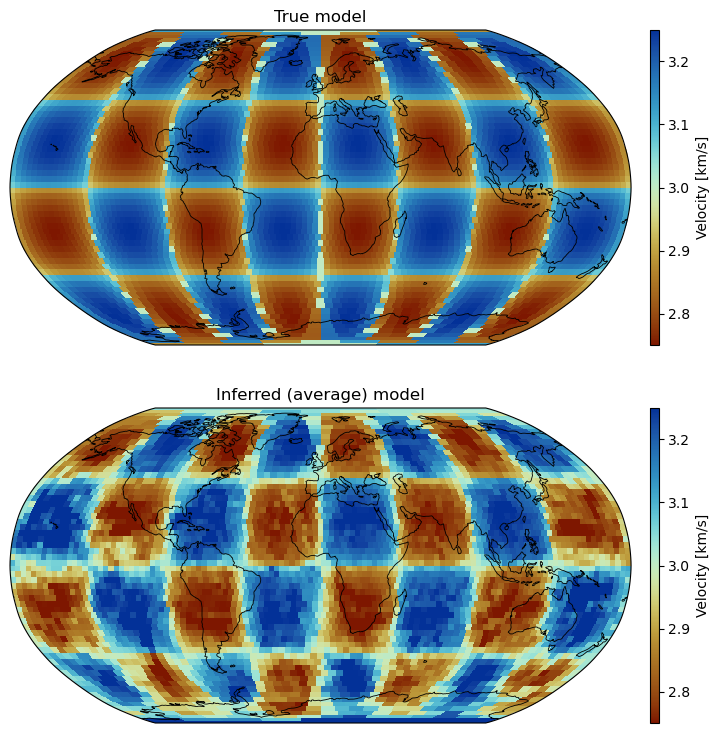

In [11]:
results = inversion.get_results()
inferred_vel = np.mean(results["interp_vel"], axis=0)

fig = plt.figure(figsize=(12, 9))
ax1 = fig.add_subplot(2, 1, 1, projection=ccrs.Robinson())
plot_map(
    vel_true, "True model", ax=ax1,
    vmin=vel_true.min(), vmax=vel_true.max()
)
ax2 = fig.add_subplot(2, 1, 2, projection=ccrs.Robinson())
plot_map(
    inferred_vel, "Inferred (average) model", ax=ax2,
    vmin=vel_true.min(), vmax=vel_true.max()
)
plt.show()

The code block below displays a few models sampled from the posterior. Each panel shows the exact spherical Voronoi cells of one sampled tessellation on a Robinson projection; all panels share the same colour scale.

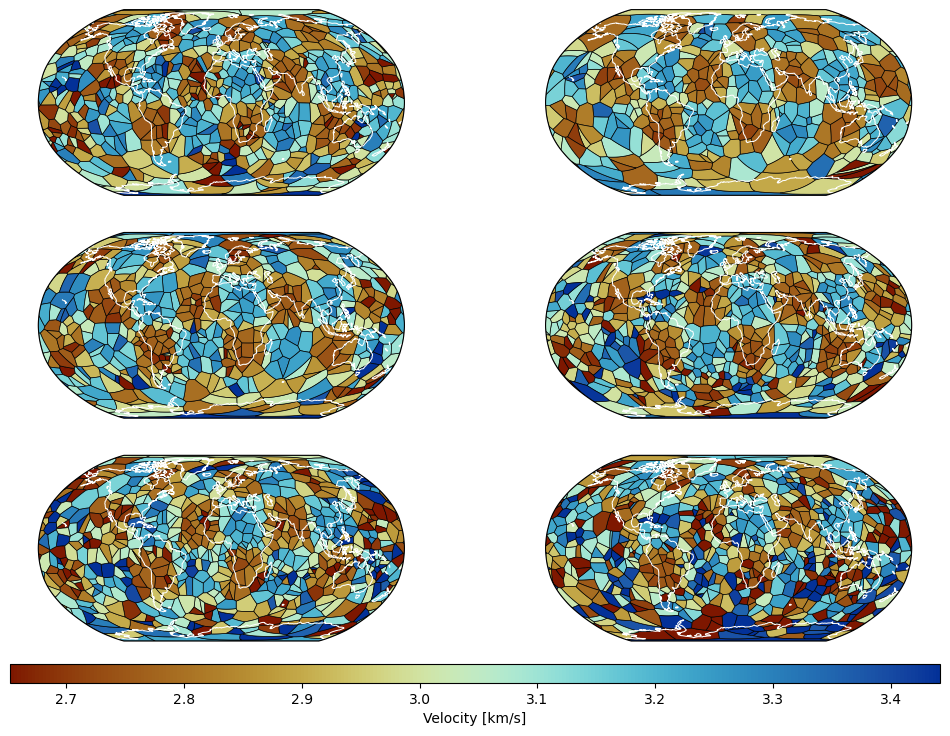

In [12]:
fig, axes = plt.subplots(
    3, 2, figsize=(12, 10), subplot_kw=dict(projection=ccrs.Robinson())
)
norm = plt.Normalize(vmin=inferred_vel.min(), vmax=inferred_vel.max())
random_indexes = rng.choice(
    range(len(results["voronoi.vel"])), size=6, replace=False
)
for ax, irandom in zip(axes.ravel(), random_indexes):
    voronoi_sites = results["voronoi.discretization"][irandom]
    velocity = results["voronoi.vel"][irandom]
    Voronoi2DSphere.plot_tessellation(
        voronoi_sites,
        velocity,
        ax=ax,
        lon_bounds=(-180, 180),
        cmap=scm.roma,
        norm=norm,
        colorbar=False,
        transform=ccrs.PlateCarree(),
    )
    # White coastlines, to stand out against the black Voronoi-cell boundaries
    ax.coastlines(resolution="110m", lw=0.75, color="white")
    ax.set_global()
cbar = fig.colorbar(
    ScalarMappable(cmap=scm.roma, norm=norm),
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    aspect=50,
    pad=0.03,
)
cbar.set_label("Velocity [km/s]")
plt.show()

A global tessellation can also be plotted on a 3-D globe. For readability, we select the sampled model with the fewest Voronoi cells, and show it from an Atlantic-centred and a Pacific-centred viewpoint, which together cover the full sphere. Both panels show the same model; only the viewing angle changes.

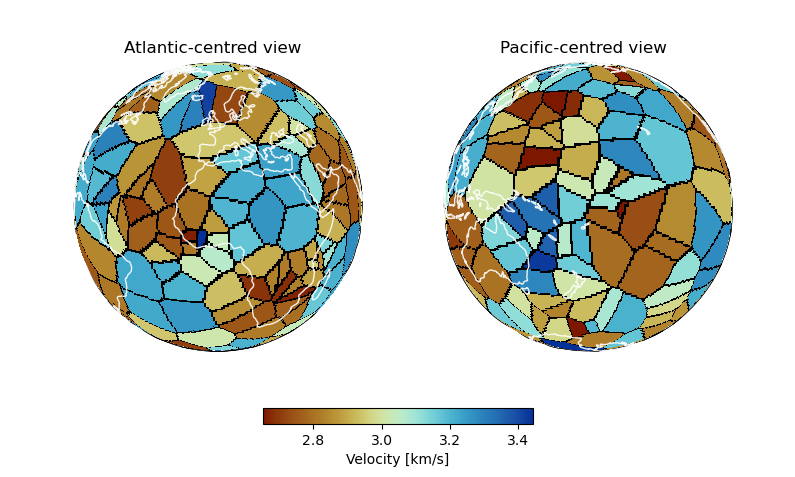

In [13]:
def load_coastline_paths(radius=1.015):
    shp = shpreader.natural_earth(
        resolution="110m", category="physical", name="coastline"
    )
    paths = []
    for geometry in shpreader.Reader(shp).geometries():
        lines = geometry.geoms if hasattr(geometry, "geoms") else [geometry]
        for line in lines:
            paths.append(
                Voronoi2DSphere.lonlat_to_xyz(np.asarray(line.coords)) * radius
            )
    return paths


def add_front_facing_coastlines(ax, coastline_paths, center_lonlat):
    view_direction = Voronoi2DSphere.lonlat_to_xyz(
        np.asarray(center_lonlat, dtype=float)[None, :]
    )[0]
    for path in coastline_paths:
        front_indices = np.flatnonzero(path @ view_direction > 0)
        if not front_indices.size:
            continue
        section_breaks = np.flatnonzero(np.diff(front_indices) > 1) + 1
        for section in np.split(front_indices, section_breaks):
            if len(section) >= 2:
                ax.plot(
                    path[section, 0],
                    path[section, 1],
                    path[section, 2],
                    color="white",
                    lw=1,
                    alpha=0.9,
                    zorder=10,
                )


irandom = min(
    range(len(results["voronoi.discretization"])),
    key=lambda i: len(results["voronoi.discretization"][i]),
)
voronoi_sites = results["voronoi.discretization"][irandom]
velocity = results["voronoi.vel"][irandom]
coastline_paths = load_coastline_paths()

fig = plt.figure(figsize=(9, 4.6))
viewpoints = [(0, 20), (180, -10)]
view_titles = ["Atlantic-centred view", "Pacific-centred view"]
for iplot, (center_lonlat, title) in enumerate(
    zip(viewpoints, view_titles), start=1
):
    ax = fig.add_subplot(1, 2, iplot, projection="3d")
    Voronoi2DSphere.plot_tessellation_3d(
        voronoi_sites,
        velocity,
        ax=ax,
        center_lonlat=center_lonlat,
        surface_spacing_deg=0.9,
        cmap=scm.roma,
        norm=norm,
        colorbar=False,
        linewidth=0.4,
    )
    add_front_facing_coastlines(ax, coastline_paths, center_lonlat)
    ax.set_axis_off()
    # Enlarge the globes and pull them together; a negative wspace removes
    # the whitespace the square 3-D axes would otherwise leave around them
    ax.set_box_aspect((1, 1, 1), zoom=1.3)
    ax.set_title(title, y=0.95)
fig.subplots_adjust(left=0, right=1, top=1, bottom=0.12, wspace=-0.3)
cbar = fig.colorbar(
    ScalarMappable(cmap=scm.roma, norm=norm),
    cax=fig.add_axes([0.35, 0.1, 0.3, 0.035]),
    orientation="horizontal",
)
cbar.set_label("Velocity [km/s]")
plt.show()

## References

(Magrini22b_global)=
[1] Magrini et al. (2022), Surface-wave tomography using SeisLib: a Python package for multiscale seismic imaging. *Geophysical Journal International*